In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nguyentiennhan/vietnam-housing-dataset-2024/vietnam_housing_dataset.csv


# Part 1: Xử lí dữ liệu

In [3]:
import kagglehub
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from category_encoders import TargetEncoder

In [4]:
path = kagglehub.dataset_download("nguyentiennhan/vietnam-housing-dataset-2024")
house_data = pd.read_csv(f"{path}/vietnam_housing_dataset.csv", encoding='utf-8')
house_data['Price_per_m2'] = (house_data['Price'] * 1000 / house_data['Area']).round(2)
house_data

,Address,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price,Price_per_m2
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN,8.60,102.38
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",60.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,7.50,125.00
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",90.0,6.0,13.0,Đông - Bắc,Đông - Bắc,5.0,NaN,NaN,Sale contract,NaN,8.90,98.89
3,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",54.0,NaN,3.5,Tây - Nam,Tây - Nam,2.0,2.0,3.0,Have certificate,Full,5.35,99.07
4,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0,NaN,NaN,Đông - Nam,Đông - Nam,2.0,4.0,4.0,Have certificate,Full,6.90,75.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
30224,"Đường Lê Quang Định, Phường 1, Gò Vấp, Hồ Chí ...",67.0,4.1,16.0,NaN,NaN,1.0,3.0,2.0,Have certificate,NaN,4.60,68.66
30225,"Đường Ngô Gia Tự, Phường Đức Giang, Long Biên,...",30.0,NaN,NaN,NaN,NaN,5.0,3.0,3.0,Have certificate,NaN,4.70,156.67
30226,"Đường Gò Dưa, Phường Tam Bình, Thủ Đức, Hồ Chí...",69.4,4.0,15.0,Đông - Bắc,Đông - Bắc,NaN,NaN,NaN,Have certificate,Basic,7.50,108.07
30227,"Đường Quang Trung, Phường 11, Gò Vấp, Hồ Chí Minh",96.0,NaN,8.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,9.50,98.96


In [5]:
# lọc dữ liệu chỉ giữ lại bản ghi ở Hà Nội
def filters(row):
    if 'Hà Nội' not in str(row['Address']):
        return False
    elif pd.isna(row['Area']) or pd.isna(row['Floors']) or pd.isna(row['Price']) or pd.isna(row['Frontage']) or pd.isna(row['Furniture state']):
        return False
    return True

hanoi_data = house_data[house_data.apply(filters, axis=1)].copy()
hanoi_data

,Address,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price,Price_per_m2
31,"Đường An Dương Vương, Phường Phú Thượng, Tây H...",72.0,5.6,3.5,NaN,NaN,1.0,NaN,NaN,Have certificate,Basic,10.00,138.89
43,"Đường Phú Mỹ, Phường Mỹ Đình 1, Nam Từ Liêm, H...",54.0,5.8,3.0,Tây - Bắc,Tây - Bắc,4.0,6.0,6.0,Have certificate,Full,8.80,162.96
44,"Đường La Phù, Xã La Phù, Hoài Đức, Hà Nội",36.0,3.8,2.2,Nam,NaN,5.0,NaN,NaN,Have certificate,Basic,3.85,106.94
66,"Ngõ 401, Đường Xuân Đỉnh, Phường Xuân Đỉnh, Bắ...",52.7,7.0,3.0,NaN,NaN,5.0,6.0,NaN,NaN,Full,7.60,144.21
77,"Đường Quang Tiến, Phường Đại Mỗ, Nam Từ Liêm, ...",36.0,7.0,3.0,Tây - Nam,Tây - Nam,5.0,3.0,4.0,Have certificate,Full,5.60,155.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...
30204,"Đường Hòa Bình, Phường Yên Nghĩa, Hà Đông, Hà Nội",32.0,3.4,3.0,Đông - Nam,Đông - Nam,4.0,3.0,3.0,Have certificate,Full,2.95,92.19
30206,"Phố Lò Đúc, Phường Đống Mác, Hai Bà Trưng, H...",40.0,8.0,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,Full,9.25,231.25
30210,"Thị trấn Chúc Sơn, Chương Mỹ, Hà Nội",30.0,6.0,NaN,Đông - Nam,Đông - Nam,3.0,3.0,2.0,Have certificate,Full,2.50,83.33
30214,"Đường Triều Khúc, Xã Tân Triều, Thanh Trì, Hà Nội",30.0,3.5,NaN,NaN,NaN,5.0,3.0,NaN,Have certificate,Full,4.98,166.00


In [6]:
# tách địa chỉ quận từ địa chỉ chi tiết và lọc các quận có quá ít bản ghi
def define_district(address):
    parts = [p.strip() for p in str(address).split(',')]
    
    reversed_parts = parts[::-1]
    
    if len(reversed_parts) > 1:
        return reversed_parts[1]
    return "Không rõ"

hanoi_data['District'] = hanoi_data['Address'].apply(define_district)
hanoi_data = hanoi_data[hanoi_data['District'] != 'Phường Việt Hưng'].copy()
hanoi_data['District'] = hanoi_data['District'].str.replace(r'Quận |Huyện ', '', regex=True)
hanoi_data = hanoi_data[~hanoi_data['District'].isin(['Ứng Hòa', 'Sơn Tây'])]
hanoi_data['District'].unique()

array(['Tây Hồ', 'Nam Từ Liêm', 'Hoài Đức', 'Bắc Từ Liêm', 'Cầu Giấy',
       'Long Biên', 'Hoàng Mai', 'Đống Đa', 'Hai Bà Trưng', 'Thanh Xuân',
       'Hà Đông', 'Chương Mỹ', 'Quốc Oai', 'Thanh Trì', 'Gia Lâm',
       'Thanh Oai', 'Ba Đình', 'Đông Anh', 'Hoàn Kiếm', 'Thường Tín',
       'Mê Linh', 'Sóc Sơn', 'Đan Phượng', 'Ba Vì'], dtype=object)

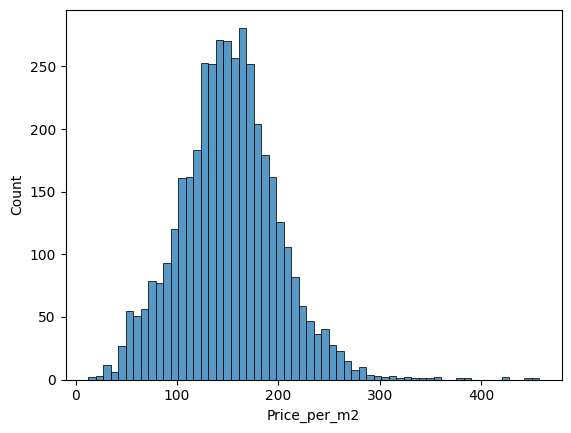

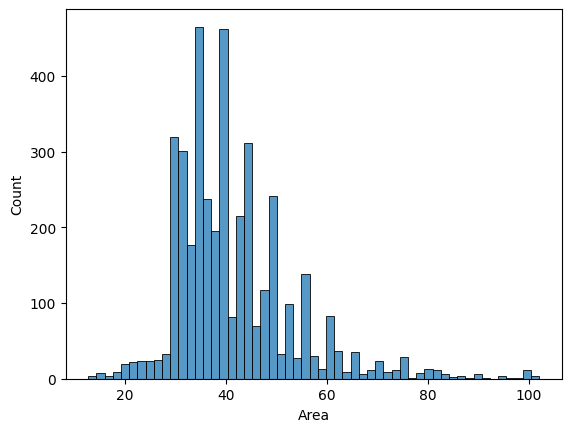

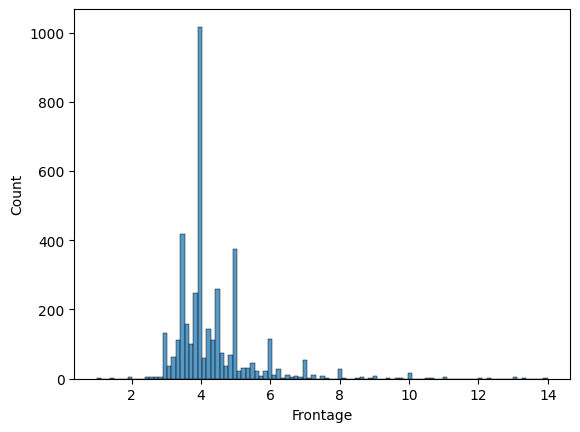

In [7]:
# lọc dữ liệu ngoại lai ở các cột giá nhà trên m2, diện tích, mặt tiền

hanoi_data = hanoi_data[hanoi_data['Price_per_m2'] < 500]
sns.histplot(hanoi_data['Price_per_m2'])
plt.show()

upper_bound = hanoi_data['Area'].quantile(0.99)
area_data = hanoi_data[hanoi_data['Area'] <= upper_bound]
sns.histplot(area_data['Area'])
plt.show()

frontage_data = area_data[area_data['Frontage'] < 20]
sns.histplot(frontage_data['Frontage'])
plt.show()

In [8]:
clean_data = frontage_data
clean_data.head()

,Address,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price,Price_per_m2,District
31,"Đường An Dương Vương, Phường Phú Thượng, Tây H...",72.0,5.6,3.5,NaN,NaN,1.0,NaN,NaN,Have certificate,Basic,10.00,138.89,Tây Hồ
43,"Đường Phú Mỹ, Phường Mỹ Đình 1, Nam Từ Liêm, H...",54.0,5.8,3.0,Tây - Bắc,Tây - Bắc,4.0,6.0,6.0,Have certificate,Full,8.80,162.96,Nam Từ Liêm
44,"Đường La Phù, Xã La Phù, Hoài Đức, Hà Nội",36.0,3.8,2.2,Nam,NaN,5.0,NaN,NaN,Have certificate,Basic,3.85,106.94,Hoài Đức
66,"Ngõ 401, Đường Xuân Đỉnh, Phường Xuân Đỉnh, Bắ...",52.7,7.0,3.0,NaN,NaN,5.0,6.0,NaN,NaN,Full,7.60,144.21,Bắc Từ Liêm
77,"Đường Quang Tiến, Phường Đại Mỗ, Nam Từ Liêm, ...",36.0,7.0,3.0,Tây - Nam,Tây - Nam,5.0,3.0,4.0,Have certificate,Full,5.60,155.56,Nam Từ Liêm


## Part 2: Trả lời câu hỏi: Liệu rằng hướng nhà phong thủy có ảnh hướng tới giá nhà?

Người Việt quan niệm rằng nên chọn ngôi nhà có hướng Nam, Đông, Đông Nam vì vậy trong phần này chúng ta sẽ sử dụng biểu đồ boxplot và A/B test với mức ý nghĩa 0.05 để tìm ra câu trả lời.

In [9]:
# tìm tương quan giữa giá nhà trên m2 và hướng nhà được phân loại theo số tầng 

def categoried_floors(Floors):
    if Floors <= 2: return 'Thấp'
    elif Floors < 5: return 'Trung bình'
    else: return 'Cao'

floor_house_data = house_data[house_data['Floors'].notna()].copy()

floor_house_data['floor_group'] = floor_house_data['Floors'].apply(categoried_floors)
floor_house_data.head()

,Address,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price,Price_per_m2,floor_group
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN,8.60,102.38,Trung bình
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",60.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,7.50,125.00,Cao
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",90.0,6.0,13.0,Đông - Bắc,Đông - Bắc,5.0,NaN,NaN,Sale contract,NaN,8.90,98.89,Cao
3,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",54.0,NaN,3.5,Tây - Nam,Tây - Nam,2.0,2.0,3.0,Have certificate,Full,5.35,99.07,Thấp
4,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0,NaN,NaN,Đông - Nam,Đông - Nam,2.0,4.0,4.0,Have certificate,Full,6.90,75.00,Thấp


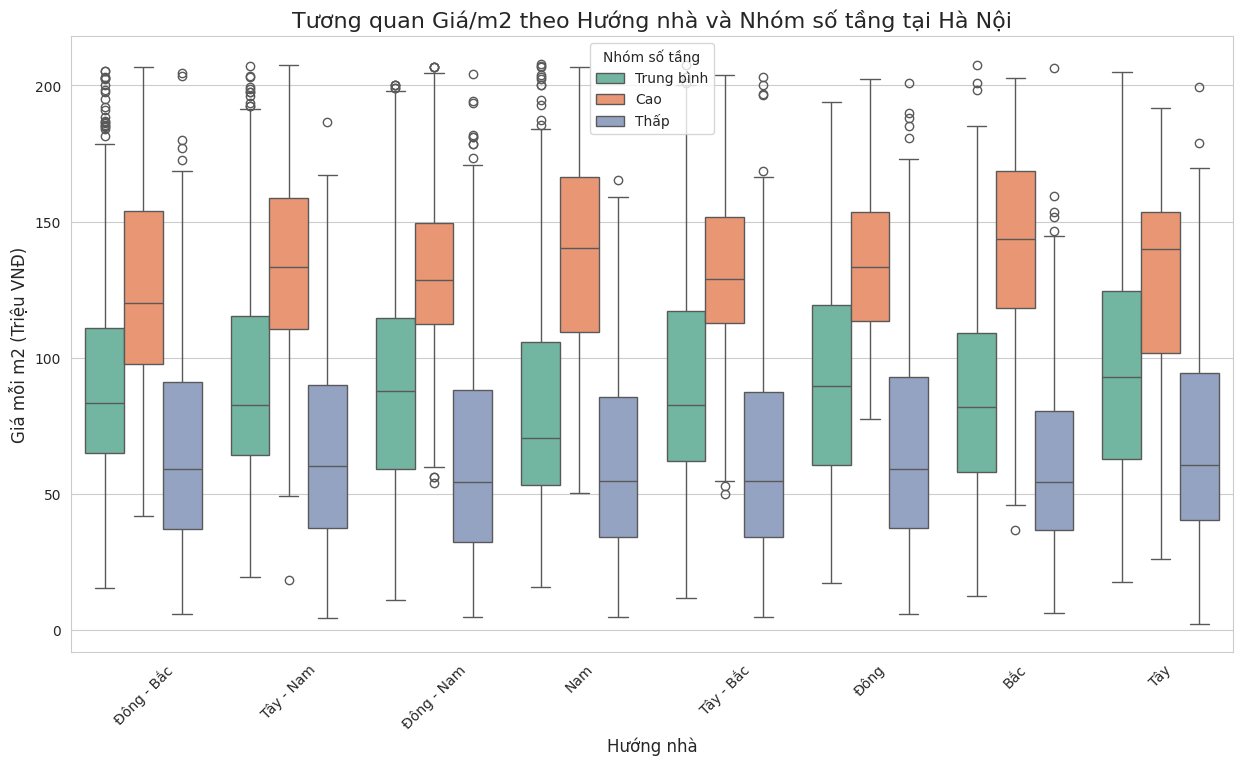

In [10]:
# dùng threshold để loại bỏ giá trị ngoại lai
threshold = floor_house_data['Price_per_m2'].quantile(0.95)
clean_floor_house_data = floor_house_data[floor_house_data['Price_per_m2'] < threshold]

plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

sns.boxplot(data=clean_floor_house_data, x='House direction', y='Price_per_m2', hue='floor_group', palette='Set2')

plt.title('Tương quan Giá/m2 theo Hướng nhà và Nhóm số tầng tại Hà Nội', fontsize=16)
plt.xlabel('Hướng nhà', fontsize=12)
plt.ylabel('Giá mỗi m2 (Triệu VNĐ)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Nhóm số tầng')
plt.show()

In [11]:

ab_data = clean_floor_house_data[
    clean_floor_house_data['House direction'].notna()
].copy()

# Các hướng được xem là tốt
good_directions = [
    'Đông - Nam',
    'Nam',
    'Đông'
]

ab_data['Label'] = np.where(
    ab_data['House direction'].isin(good_directions),
    'good',
    'other'
)

ab_data['Price_per_m2'] = (
    ab_data['Price'] * 1000 / ab_data['Area']
)

ab_data[['House direction', 'Label', 'Price_per_m2']].head()

,House direction,Label,Price_per_m2
2,Đông - Bắc,other,98.888889
3,Tây - Nam,other,99.074074
4,Đông - Nam,good,75.000000
7,Nam,good,133.783784
10,Đông - Nam,good,125.000000


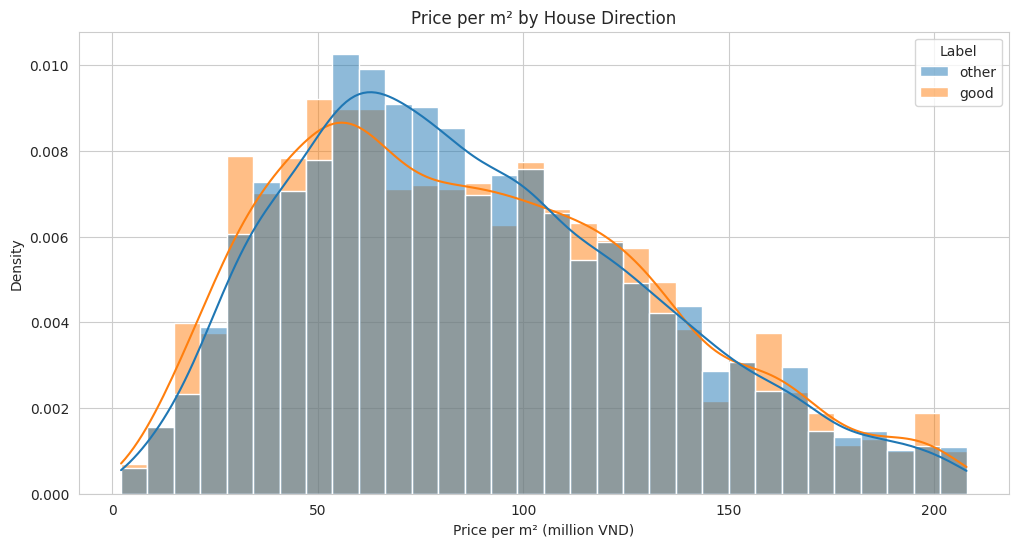

In [12]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=ab_data,
    x='Price_per_m2',
    hue='Label',
    kde=True,
    stat='density',

    common_norm=False
)

plt.title('Price per m² by House Direction')
plt.xlabel('Price per m² (million VND)')
plt.show()

In [13]:
def test_statistic(df):
    good_mean = df[
        df['Label'] == 'good'
    ]['Price_per_m2'].mean()

    other_mean = df[
        df['Label'] == 'other'
    ]['Price_per_m2'].mean()

    return good_mean - other_mean

observed_statistic = test_statistic(ab_data)

print("Observed statistic:", observed_statistic)

Observed statistic: -0.14629268301140996


In [14]:
def simulate_null(df):

    shuffled_labels = np.random.permutation(
        df['Label']
    )

    shuffled_df = df.copy()

    shuffled_df['Label'] = shuffled_labels

    return test_statistic(shuffled_df)

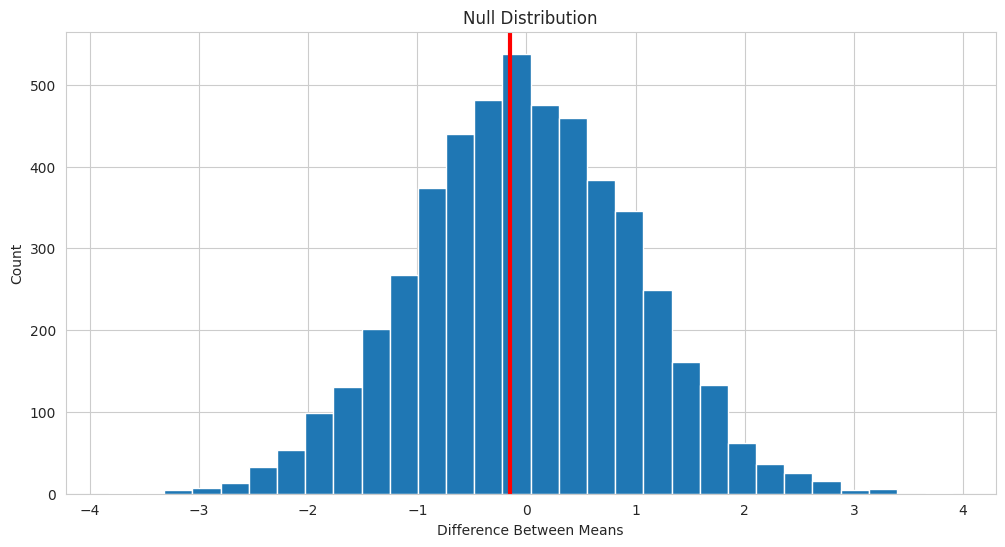

In [15]:
sampled_stats = np.array([])

repetitions = 5000

for i in range(repetitions):

    simulated_stat = simulate_null(ab_data)

    sampled_stats = np.append(
        sampled_stats,
        simulated_stat
    )

plt.figure(figsize=(12,6))
plt.hist(sampled_stats, bins=30)
plt.axvline(
    observed_statistic,
    color='red',
    linewidth=3
)
plt.title('Null Distribution')
plt.xlabel('Difference Between Means')
plt.ylabel('Count')

plt.show()

In [16]:
p_value = np.mean(
    sampled_stats >= observed_statistic
)

print("P-value:", p_value)

P-value: 0.551


**Vì P-value lớn hơn mức ý nghĩa nên không thể bác bỏ giả thuyết null, điều đó có nghĩa chúng ta không thể kết luận rằng hướng nhà có ảnh hướng đáng kể đến giá ngôi nhà.**

# Part 3: Dự đoán giá nhà

<Figure size 1000x800 with 0 Axes>

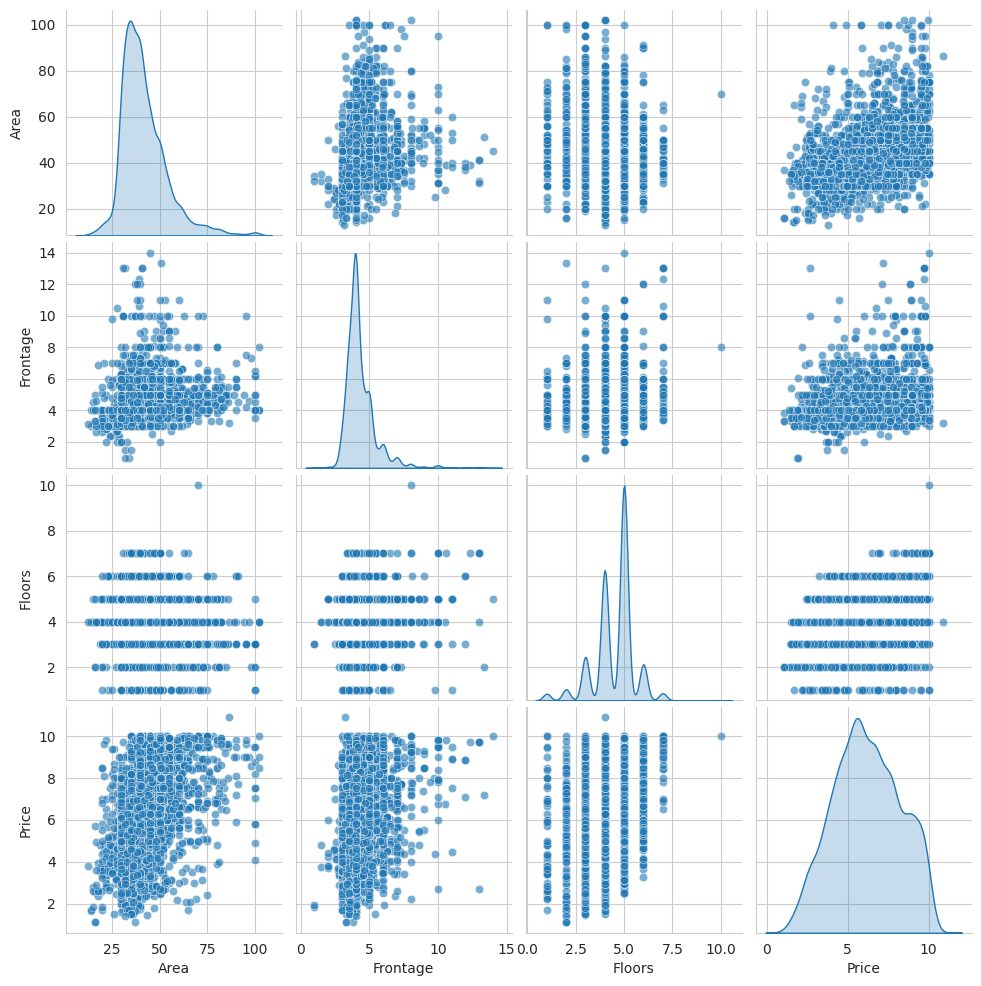

In [17]:
columns_to_plot = ["Area", "Frontage", "Floors", "Price"]

plt.figure(figsize=(10, 8))
sns.pairplot(
    clean_data[columns_to_plot], diag_kind="kde", plot_kws={"alpha": 0.6}
)

plt.show()

**Sử dụng mô hình fully connected**

In [18]:
# chuẩn bị dữ liệu để huấn luyện mô hình
x = clean_data[['Area', 'Frontage', 'Floors', 'Furniture state', 'District']]
y = clean_data['Price']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=x['District'], random_state=42)

encoder = TargetEncoder(cols=['District'], min_samples_leaf=2, smoothing=1.0)

x_train['District'] = encoder.fit_transform(x_train['District'], y_train)
x_test['District'] = encoder.transform(x_test['District'])

x_train['Furniture state'] = x_train['Furniture state'].map({'Basic': 0}).fillna(1).astype(int)
x_test['Furniture state'] = x_test['Furniture state'].map({'Basic': 0}).fillna(1).astype(int)

scaler = StandardScaler()

x_train_normalized = scaler.fit_transform(x_train)
x_test_normalized = scaler.transform(x_test)

In [19]:
# xây dựng mô hình ANN fully connected và huấn luyện, đánh giá

import torch
import torch.nn as nn
import torch.optim as optim
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.fc = nn.Sequential(
            nn.Linear(5, 64),
            nn.BatchNorm1d(num_features=64),
            nn.ReLU(),

            nn.Linear(64, 256),
            nn.BatchNorm1d(num_features=256),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256, 512),
            nn.BatchNorm1d(num_features=512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, 256),
            nn.BatchNorm1d(num_features=256),
            nn.ReLU(),
            nn.Dropout(0.5),
            
            nn.Linear(256, 64),
            nn.BatchNorm1d(num_features=64),
            nn.ReLU(),
            
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.fc(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
x_train_tensor = torch.tensor(x_train_normalized, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).to(device).unsqueeze(1)
x_test_tensor = torch.tensor(x_test_normalized, dtype=torch.float32).to(device)

ann = ANN().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(ann.parameters(), lr=0.001)

epochs = 400
train_loss = []

for epoch in range(epochs):
    ann.train()

    output = ann(x_train_tensor)
    loss = criterion(output, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_loss.append(loss.item())

ann.eval()

with torch.no_grad(): 

    predictions_tensor = ann(x_test_tensor)
    
    y_pred = predictions_tensor.cpu().numpy()


Biểu đồ giá trị Loss

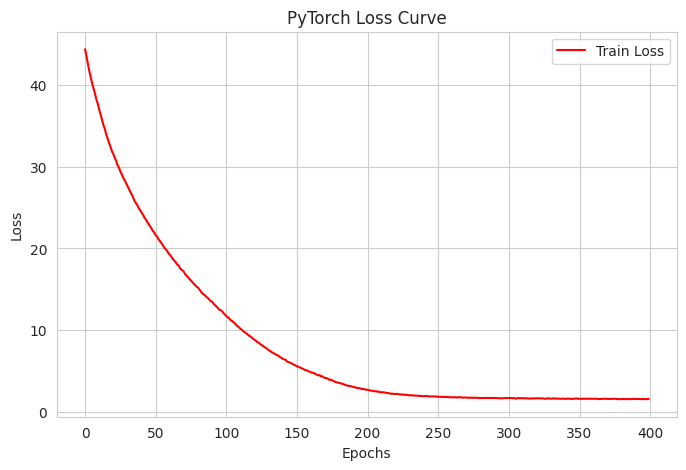

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(train_loss, label="Train Loss", color="red")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("PyTorch Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
r2 = r2_score(y_test, y_pred)
print(r2)

mse = mean_squared_error(y_test, y_pred)
print(mse)

0.5442485609048358
1.9295498801789797


Sử dụng thuật toán Random Forest Regressor

In [22]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)

model_rf.fit(x_train_normalized, y_train)

y_pred_rf = model_rf.predict(x_test_normalized)
r2_rf = r2_score(y_test, y_pred_rf)
print(r2_rf)

mse_rf = mean_squared_error(y_test, y_pred_rf)
print(mse_rf)

0.5967067268868839
1.7074537128338356
